In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from cloudcasting.dataset import SatelliteDataModule, SatelliteDataset

torch.manual_seed(0)
np.random.seed(0)

In [ ]:
# Instantiate the torch dataset object
dataset = SatelliteDataset(
    zarr_path="../data/2020_training_nonhrv.zarr",
    start_time="2020-06-01",
    end_time="2020-06-15",
    history_mins=60,
    forecast_mins=180,
    sample_freq_mins=15,
)

In [ ]:
# Number of complete samples in the dataset
# - this includes overlapping periods, not completely distinct periods
n_samples = len(dataset)
print(n_samples)

In [12]:
# Speed test
%timeit -n 3 -r 10 dataset[np.random.randint(n_samples)]

The slowest run took 6.43 times longer than the fastest. This could mean that an intermediate result is being cached.
427 ms ± 389 ms per loop (mean ± std. dev. of 10 runs, 3 loops each)


In [13]:
# Index out a single sample
X, y = dataset[30]

In [14]:
type(X)

numpy.ndarray

In [15]:
X.shape # (channels, time, height, width)

(11, 5, 372, 614)

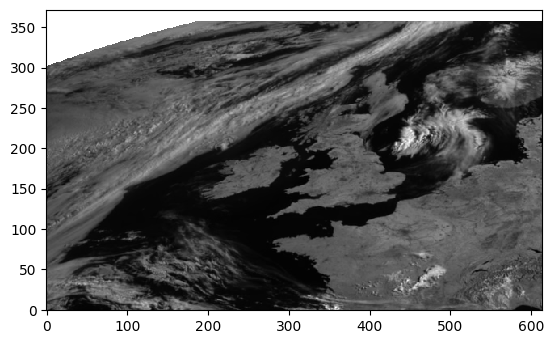

In [16]:
# Slice a single image from the input data and select a single channel
# The channel at index 8 is the VIS008 visual channel
single_image = X[8, 0]

# Need to reverse the x-axis since the data is reversed in this dimension on disk
single_image = single_image[:, ::-1]

plt.imshow(single_image, cmap='gist_grey', interpolation='nearest', origin="lower")
plt.show()

In [47]:
# Instantiate a lightning datamodule
datamodule = SatelliteDataModule(
    zarr_path="../data/2020_training_nonhrv.zarr",
    history_mins=60,
    forecast_mins=180,
    sample_freq_mins=15,
    batch_size=8,
    num_workers=0,
    #prefetch_factor=2,
    train_period=["2020-06-01", "2020-06-19"],
    val_period=["2020-06-20", "2020-06-25"],
    test_period=["2020-06-26", "2020-06-30"],
)

In [48]:
# Instantiate the train dataloader
train_dataloader = datamodule.train_dataloader()

In [49]:
t_last = time.time()

for i, (_X, _y) in zip(range(5), train_dataloader, strict=False):
    t_now = time.time()
    print(f"Batch {i} took: {t_now - t_last:.3f} seconds")
    print("X:", _X.shape, _X.dtype)
    print("y:", _y.shape, _y.dtype)
    t_last = t_now

Batch 0 took: 1.827 seconds
X: torch.Size([8, 11, 5, 372, 614]) torch.float32
y: torch.Size([8, 11, 12, 372, 614]) torch.float32
Batch 1 took: 1.823 seconds
X: torch.Size([8, 11, 5, 372, 614]) torch.float32
y: torch.Size([8, 11, 12, 372, 614]) torch.float32
Batch 2 took: 1.882 seconds
X: torch.Size([8, 11, 5, 372, 614]) torch.float32
y: torch.Size([8, 11, 12, 372, 614]) torch.float32
Batch 3 took: 1.790 seconds
X: torch.Size([8, 11, 5, 372, 614]) torch.float32
y: torch.Size([8, 11, 12, 372, 614]) torch.float32
Batch 4 took: 1.794 seconds
X: torch.Size([8, 11, 5, 372, 614]) torch.float32
y: torch.Size([8, 11, 12, 372, 614]) torch.float32


In [41]:
# Lets grab the last batch the dataloader yielded
X = _X
y = _y

In [42]:
type(X)

torch.Tensor

In [43]:
X.shape # (batch size, channels, time, height, width)

torch.Size([4, 11, 5, 372, 614])

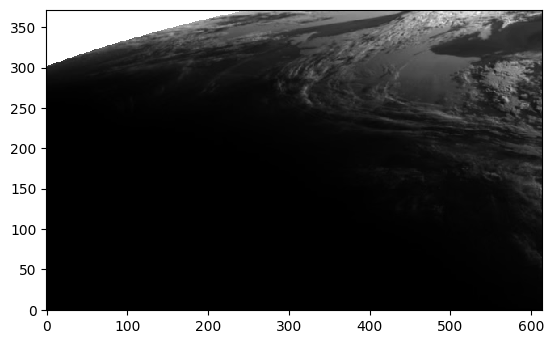

In [44]:
# Slice the VIS008 channel from a single image from the input data
single_image = X[0, 8, 0].numpy()

# Need to reverse the x-axis since the data is reversed in this dimension on disk
single_image = single_image[:, ::-1]

plt.imshow(single_image, cmap='gist_grey', interpolation='nearest', origin="lower")
plt.show()

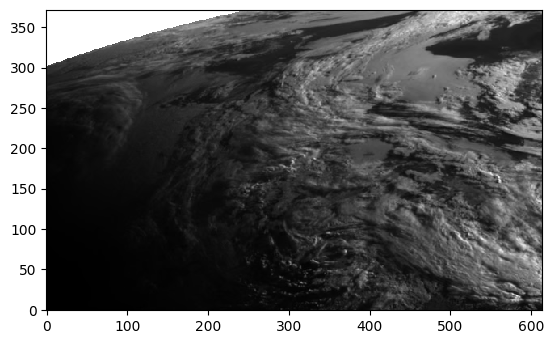

In [45]:
# Slice the accompanying target for the above
single_image = y[0, 8, 0].numpy()

single_image = single_image[:, ::-1]

plt.imshow(single_image, cmap='gist_grey', interpolation='nearest', origin="lower")
plt.show()

Looks like this example was towards dusk. Channel 8 which we plotted above is one of the visual channels, and we can't see what is happening in the bottom right. But we could see what is happening if we use one of the IR channels

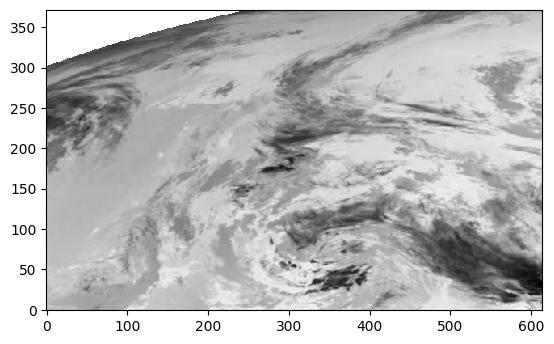

In [46]:
# Select one of the infrared channels for the image above
# the channel at index 2 is the IR_087 channel
single_image = y[0, 2, 0].numpy()
single_image = single_image[:, ::-1]

plt.imshow(single_image, cmap='gist_grey', interpolation='nearest', origin="lower")
plt.show()